# 03 · 보드 위 물체 분할 (고전 필터, 무학습)

ML/딥러닝 없이 **색 필터 + 기하 정보**만으로 보드 위 물체를 뽑아낸다. 이 프로젝트의 핵심 모듈.

**두 가지를 결합 (검증된 조합):**
1. **물체 색 지정** — 물체(예: 파란 립밤)의 HSV 색창으로 필터. 색은 물체 위 작은 ROI를 샘플링해 자동 설정하거나 수동 지정.
2. **보드-연결 필터** — 검출한 보드 영역에 *닿아 있는* 덩어리만 남김. 키보드·손·배경처럼 보드 밖의 같은색 물체를 제거. (세운 물체는 이미지에서 보드 위로 솟으므로 영역으로 *자르지 않고* '연결'만 본다.)

> 왜 채도(S)가 열쇠인가: 이 웹캠에선 검은 보드칸도 어두운 파랑(H~107)으로 찍혀 색상만으론 물체와 안 갈린다. 하지만 물체(진한 파랑)는 **채도가 훨씬 높아** S 임계로 깔끔히 분리된다.

In [1]:
import os, sys, glob, json
import cv2
import numpy as np
import matplotlib.pyplot as plt

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, os.path.join(ROOT, 'src'))
import aruco_utils as au
print('OpenCV', cv2.__version__)

SCENE_DIR = os.path.join(ROOT, 'data', 'scene_images')
OUTPUT_DIR = os.path.join(ROOT, 'output')

# ===== 설정 =====
SCENE_IMAGE = None       # None이면 scene_images/ 첫 이미지
SQUARES_X, SQUARES_Y = 5, 7
SQUARE_LENGTH_M = 0.038
MARKER_LENGTH_M = 0.038 * 22 / 30
ARUCO_DICT = cv2.aruco.DICT_5X5_1000

OpenCV 4.13.0


In [2]:
# 이미지 + 캘리브레이션 + 보드 포즈
if SCENE_IMAGE is None:
    files = []
    for e in ('*.jpg','*.jpeg','*.png','*.bmp','*.JPG','*.JPEG','*.PNG'):
        files.extend(glob.glob(os.path.join(SCENE_DIR, e)))
    scene_path = sorted(set(files))[0]
else:
    scene_path = os.path.join(SCENE_DIR, SCENE_IMAGE)
img = cv2.imread(scene_path); assert img is not None
print('이미지:', os.path.basename(scene_path), img.shape[1], 'x', img.shape[0])

intr_path = os.path.join(OUTPUT_DIR, 'camera_intrinsics.npz')
assert os.path.exists(intr_path), '먼저 01 캘리브레이션 필요'
K, dist = au.load_intrinsics(intr_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
dictionary = cv2.aruco.getPredefinedDictionary(ARUCO_DICT)
board = cv2.aruco.CharucoBoard((SQUARES_X, SQUARES_Y), SQUARE_LENGTH_M, MARKER_LENGTH_M, dictionary)
rvec, tvec, cc, ci = au.detect_charuco_pose(gray, board, K, dist)
assert rvec is not None, '보드 검출 실패'
region, hull = au.board_region_mask(img.shape, cc, dilate_px=25)
print('보드 검출 OK, charuco 코너', len(cc))

이미지: WIN_20260705_00_38_09_Pro.jpg 1920 x 1080
보드 검출 OK, charuco 코너 19


## 물체 색 지정

**방법 A (권장): `SAMPLE_ROI`** — 물체 위 확실히 물체인 작은 사각형 `[x, y, w, h]`. 그 색을 샘플링해 HSV 창을 자동 설정.

**방법 B: 수동** — `SAMPLE_ROI=None`으로 두고 `HSV_LOW/HIGH` 직접 지정.

아래 그림(눈금)으로 물체 위 좌표를 읽어 `SAMPLE_ROI`를 정한다.

d:\python\envs\vision_aruco\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47932 (\N{HANGUL SYLLABLE MUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python\envs\vision_aruco\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python\envs\vision_aruco\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python\envs\vision_aruco\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51340 (\N{HANGUL SYLLABLE JWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python\envs\vision_aruco\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_

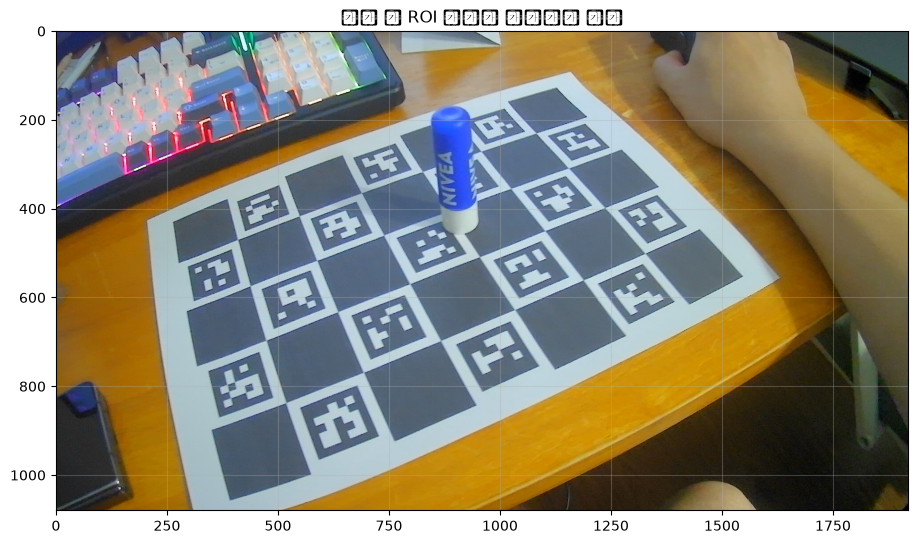

In [3]:
plt.figure(figsize=(11, 7)); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('물체 위 ROI 좌표를 눈금으로 확인'); plt.grid(True, alpha=0.3); plt.show()

In [4]:
# 방법 A: 물체 위 작은 ROI [x,y,w,h] (예시 — 실제 물체 위로 수정)
SAMPLE_ROI = [860, 210, 60, 60]
# 방법 B: 수동 HSV (SAMPLE_ROI=None일 때 사용). 파란 물체 기본값
HSV_LOW  = (90, 120, 110)
HSV_HIGH = (140, 255, 255)

if SAMPLE_ROI is not None:
    HSV_LOW, HSV_HIGH = au.auto_hsv_window_from_roi(img, SAMPLE_ROI)
    print('자동 HSV 창: low', HSV_LOW.tolist(), 'high', HSV_HIGH.tolist())
else:
    print('수동 HSV 창:', HSV_LOW, HSV_HIGH)

mask, contour, bbox = au.segment_by_color(img, HSV_LOW, HSV_HIGH, region,
                                          open_px=5, close_px=9, min_touch=30)
assert contour is not None, '물체를 못 찾음 — ROI/HSV 조정'
x, y, w, h = bbox
print(f'물체 bbox: x{x} y{y} w{w} h{h}  area={int(cv2.contourArea(contour))}px')

자동 HSV 창: low [99, 182, 170] high [129, 255, 255]
물체 bbox: x848 y186 w92 h217  area=10353px


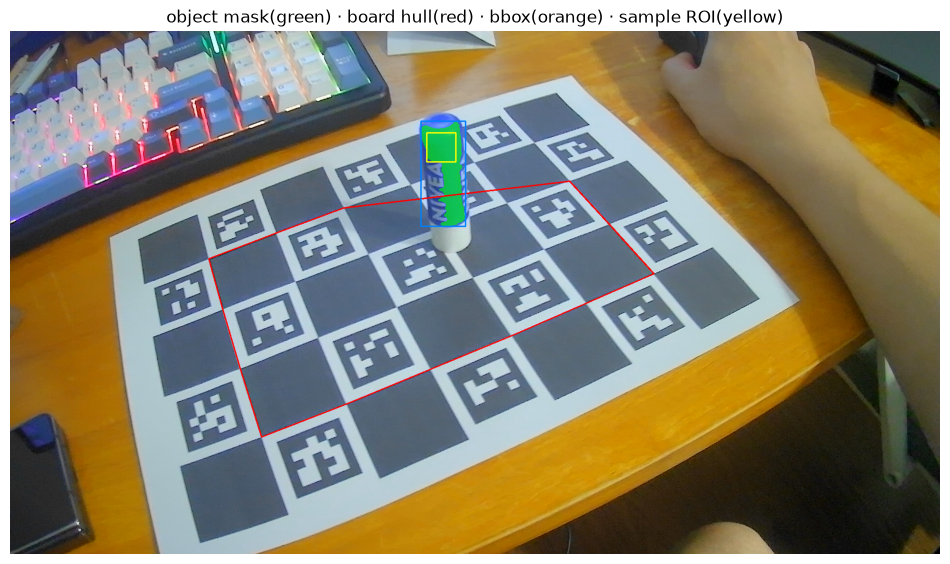

In [5]:
# 시각화
ov = img.copy()
ov[mask > 0] = (0.35 * ov[mask > 0] + np.array([0, 255, 0]) * 0.65).astype(np.uint8)
cv2.polylines(ov, [hull], True, (0, 0, 255), 2)
cv2.rectangle(ov, (x, y), (x+w, y+h), (255, 128, 0), 2)
if SAMPLE_ROI is not None:
    rx, ry, rw, rh = SAMPLE_ROI
    cv2.rectangle(ov, (rx, ry), (rx+rw, ry+rh), (0, 255, 255), 2)
plt.figure(figsize=(12, 7)); plt.imshow(cv2.cvtColor(ov, cv2.COLOR_BGR2RGB))
plt.title('object mask(green) · board hull(red) · bbox(orange) · sample ROI(yellow)')
plt.axis('off'); plt.show()

In [6]:
# 마스크 저장 (04 측정에서 사용)
mask_path = os.path.join(OUTPUT_DIR, 'object_mask.png')
cv2.imwrite(mask_path, mask)
# 물체 접점(바닥) 후보 / 꼭대기 후보 픽셀도 기록
pts = contour.reshape(-1, 2)
base_px = pts[np.argmax(pts[:, 1])].tolist()   # 가장 아래
top_px = pts[np.argmin(pts[:, 1])].tolist()    # 가장 위
info = {'scene_image': os.path.basename(scene_path), 'bbox': [int(x), int(y), int(w), int(h)],
        'base_px': base_px, 'top_px': top_px,
        'hsv_low': [int(v) for v in HSV_LOW], 'hsv_high': [int(v) for v in HSV_HIGH]}
with open(os.path.join(OUTPUT_DIR, 'object_mask.json'), 'w', encoding='utf-8') as f:
    json.dump(info, f, ensure_ascii=False, indent=2)
print('저장:', mask_path)
print(json.dumps(info, ensure_ascii=False, indent=2))

저장: d:\vision algorithm\output\object_mask.png
{
  "scene_image": "WIN_20260705_00_38_09_Pro.jpg",
  "bbox": [
    848,
    186,
    92,
    217
  ],
  "base_px": [
    895,
    402
  ],
  "top_px": [
    918,
    186
  ],
  "hsv_low": [
    99,
    182,
    170
  ],
  "hsv_high": [
    129,
    255,
    255
  ]
}


## 튜닝 & 다음

- **물체가 덜 잡히면**: `SAMPLE_ROI`를 물체의 더 진한(채도 높은) 부분으로, 또는 수동 `HSV_LOW`의 S 하한을 낮춘다.
- **주변이 딸려오면**: S 하한을 높이거나 `open_px`를 키운다.
- **흰색/무채색 물체**엔 색 필터가 약하다 → 이때는 '보드 배경(흑백) 예측 후 차분(known-background subtraction)' 방식으로 확장 예정.
- 다음(`04`): 이 마스크의 바닥접점(base_px)과 수직 모서리로 `02`의 평면 역투영·높이 계산을 연결해 **물체 크기(W×L×H)** 를 자동 산출.
- 이후: 마커/물체 ID → 메타정보 매핑, 실시간 촬영·삭제 루프.